# FEM Surrogate — Entraînement du modèle

Ce notebook permet d'entraîner le modèle LightGBM complet depuis les splits déjà préparés.

**Étapes :**
1. Chargement des données
2. Préparation des features
3. Hyperparamètres (réglage manuel ou Optuna)
4. Entraînement
5. Évaluation
6. Sauvegarde du modèle

In [21]:
import sys
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import OrdinalEncoder

ROOT      = pathlib.Path('..')
PROC_DIR  = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'data' / 'models' / 'advanced'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

EPS         = 1e-12
TARGET_COLS = ['max_displacement_m', 'max_von_mises_pa']
DROP_COLS   = ['simulation_id', 'timestamp', 'solver_name', 'solver_version',
               'data_version', 'mesh_nx', 'mesh_ny']
CAT_COLS    = ['geometry_type', 'material_category', 'dimension_category']

print('OK')

OK


---
## 1. Chargement des données

In [22]:
train = pd.read_parquet(PROC_DIR / 'train.parquet')
val   = pd.read_parquet(PROC_DIR / 'val.parquet')
test  = pd.read_parquet(PROC_DIR / 'test.parquet')

print(f'Train : {len(train):,} lignes')
print(f'Val   : {len(val):,} lignes')
print(f'Test  : {len(test):,} lignes')
print(f'Colonnes : {list(train.columns)}')

Train : 42,855 lignes
Val   : 9,341 lignes
Test  : 9,354 lignes
Colonnes : ['simulation_id', 'timestamp', 'max_displacement_m', 'max_von_mises_pa', 'solver_name', 'solver_version', 'data_version', 'material_category', 'dimension_category', 'length_m', 'height_m', 'young_modulus_pa', 'poisson_ratio', 'traction_pa', 'mesh_nx', 'mesh_ny', 'hole_radius_ratio', 'geometry_type', 'hole_cx_ratio', 'hole_cy_ratio', 'has_hole', 'has_moving_hole', 'area_m2', 'aspect_ratio', 'radius_abs', 'd_over_W', 'Kt_theory', 'net_section_ratio', 'sigma_net', 'epsilon', 'delta_theory', 'biaxial_factor', 'lig_left', 'lig_right', 'lig_bottom', 'lig_top', 'lig_min', 'edge_ratio', 'eccentricity_x', 'eccentricity_y', 'eccentricity', 'stress_amp_proxy', 'logE', 'logS', 'log_epsilon', 'log_delta_th', 'log_sigma_net', 'log_Kt', 'log_lig_min', 'log_edge_ratio', 'traction_over_E']


---
## 2. Préparation des features

In [23]:
feat_cols = [c for c in train.columns if c not in TARGET_COLS + DROP_COLS]
print(f'Features : {len(feat_cols)}')
print(feat_cols)

# Encodage ordinal des catégorielles
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
for df_ in [train, val, test]:
    df_[CAT_COLS] = enc.fit_transform(df_[CAT_COLS].astype(str))

X_train = train[feat_cols].astype(float)
X_val   = val[feat_cols].astype(float)
X_test  = test[feat_cols].astype(float)

print(f'\nNulls train : {X_train.isnull().sum().sum()}')
print(f'Nulls val   : {X_val.isnull().sum().sum()}')
print(f'Nulls test  : {X_test.isnull().sum().sum()}')

Features : 42
['material_category', 'dimension_category', 'length_m', 'height_m', 'young_modulus_pa', 'poisson_ratio', 'traction_pa', 'hole_radius_ratio', 'geometry_type', 'hole_cx_ratio', 'hole_cy_ratio', 'has_hole', 'has_moving_hole', 'area_m2', 'aspect_ratio', 'radius_abs', 'd_over_W', 'Kt_theory', 'net_section_ratio', 'sigma_net', 'epsilon', 'delta_theory', 'biaxial_factor', 'lig_left', 'lig_right', 'lig_bottom', 'lig_top', 'lig_min', 'edge_ratio', 'eccentricity_x', 'eccentricity_y', 'eccentricity', 'stress_amp_proxy', 'logE', 'logS', 'log_epsilon', 'log_delta_th', 'log_sigma_net', 'log_Kt', 'log_lig_min', 'log_edge_ratio', 'traction_over_E']

Nulls train : 0
Nulls val   : 0
Nulls test  : 0


---
## 3. Configuration de l'entraînement

**Deux modes :**
- `USE_OPTUNA = False` → entraîne directement avec les hyperparamètres définis dans `MANUAL_PARAMS` (rapide, ~1 min)
- `USE_OPTUNA = True` → recherche automatique des meilleurs hyperparamètres (lent, 20-60 min selon `N_TRIALS`)

In [24]:
# ── Choix du mode ─────────────────────────────────────────────────────────────
USE_OPTUNA = False   # True = recherche Optuna | False = paramètres manuels
N_TRIALS   = 40     # Nombre de trials Optuna (ignoré si USE_OPTUNA=False)
CV_FOLDS   = 5      # Folds pour la cross-validation Optuna

# ── Hyperparamètres manuels ───────────────────────────────────────────────────
# Modifier ces valeurs pour affiner le modèle sans passer par Optuna.
MANUAL_PARAMS = {
    'n_estimators':      1000,
    'learning_rate':     0.05,
    'num_leaves':        127,
    'max_depth':         8,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
}

# ── Contraintes de monotonie (physique) ───────────────────────────────────────
MONO_CONSTRAINTS_MAP = {
    'traction_pa':       +1,
    'young_modulus_pa':  -1,
    'logS':              +1,
    'logE':              -1,
    'log_sigma_net':     +1,
    'sigma_net':         +1,
    'log_delta_th':      +1,
    'delta_theory':      +1,
    'epsilon':           +1,
    'hole_radius_ratio': +1,
    'd_over_W':          +1,
    'Kt_theory':         +1,
    'edge_ratio':        +1,
    'net_section_ratio': -1,
    'lig_min':           -1,
}
mono_constraints = [MONO_CONSTRAINTS_MAP.get(c, 0) for c in feat_cols]

print(f'Mode : {"Optuna (" + str(N_TRIALS) + " trials)" if USE_OPTUNA else "Paramètres manuels"}')
print(f'Targets à entraîner : {TARGET_COLS}')

Mode : Paramètres manuels
Targets à entraîner : ['max_displacement_m', 'max_von_mises_pa']


---
## 4. Entraînement

In [25]:
def optuna_objective(trial, X_tr, y_tr, cv, mono):
    params = {
        'objective':            'regression',
        'metric':               'rmse',
        'verbosity':            -1,
        'n_estimators':         trial.suggest_int('n_estimators', 400, 2000, step=100),
        'learning_rate':        trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':           trial.suggest_int('num_leaves', 31, 255),
        'max_depth':            trial.suggest_int('max_depth', 4, 12),
        'min_child_samples':    trial.suggest_int('min_child_samples', 10, 100),
        'subsample':            trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':     trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':            trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':           trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'monotone_constraints': mono,
        'n_jobs': -1, 'random_state': 42,
    }
    rmses = []
    for tr_idx, vl_idx in cv.split(X_tr):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_tr.iloc[tr_idx], y_tr[tr_idx],
              eval_set=[(X_tr.iloc[vl_idx], y_tr[vl_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
        rmses.append(np.sqrt(mean_squared_error(y_tr[vl_idx], m.predict(X_tr.iloc[vl_idx]))))
    return float(np.mean(rmses))


trained_models = {}
best_params_per_target = {}

for target in TARGET_COLS:
    print(f'\n{"="*55}')
    print(f'  Target : {target}')
    print(f'{"="*55}')

    y_train_log = np.log10(train[target].clip(EPS).values)
    y_val_log   = np.log10(val[target].clip(EPS).values)

    if USE_OPTUNA:
        print(f'  Optuna : {N_TRIALS} trials, {CV_FOLDS}-fold CV ...')
        cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(lambda t: optuna_objective(t, X_train, y_train_log, cv, mono_constraints),
                       n_trials=N_TRIALS, show_progress_bar=True)
        best_params = study.best_params
        print(f'  Meilleur RMSE(log) CV : {study.best_value:.5f}')
        print(f'  Meilleurs params : {best_params}')
    else:
        best_params = MANUAL_PARAMS.copy()
        print(f'  Paramètres manuels utilisés.')

    best_params_per_target[target] = best_params

    # Entraînement final
    final_params = {
        'objective': 'regression', 'metric': 'rmse', 'verbosity': -1,
        'monotone_constraints': mono_constraints,
        'n_jobs': -1, 'random_state': 42,
        **best_params,
    }
    model = lgb.LGBMRegressor(**final_params)
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
    )
    trained_models[target] = model
    print(f'  Entraînement terminé. best_iteration={model.best_iteration_}')

print('\nTous les modèles entraînés.')


  Target : max_displacement_m
  Paramètres manuels utilisés.
[100]	valid_0's rmse: 0.0702882
[200]	valid_0's rmse: 0.0567788
[300]	valid_0's rmse: 0.052635
[400]	valid_0's rmse: 0.0516702
[500]	valid_0's rmse: 0.0512133
[600]	valid_0's rmse: 0.050782
[700]	valid_0's rmse: 0.0506816
  Entraînement terminé. best_iteration=680

  Target : max_von_mises_pa
  Paramètres manuels utilisés.
[100]	valid_0's rmse: 0.0387095
[200]	valid_0's rmse: 0.0331438
[300]	valid_0's rmse: 0.0318157
[400]	valid_0's rmse: 0.0312422
[500]	valid_0's rmse: 0.0308727
[600]	valid_0's rmse: 0.0307117
[700]	valid_0's rmse: 0.0305917
[800]	valid_0's rmse: 0.0305051
[900]	valid_0's rmse: 0.0304268
[1000]	valid_0's rmse: 0.030377
  Entraînement terminé. best_iteration=996

Tous les modèles entraînés.


---
## 5. Évaluation

In [26]:
def evaluate(model, X, y_orig):
    y_log   = np.log10(y_orig.clip(EPS))
    p_log   = model.predict(X)
    p_orig  = 10 ** p_log
    return {
        'R2_log':    r2_score(y_log, p_log),
        'RMSE_log':  np.sqrt(mean_squared_error(y_log, p_log)),
        'R2_orig':   r2_score(y_orig, p_orig),
        'RMSE_orig': np.sqrt(mean_squared_error(y_orig, p_orig)),
        'MAE_orig':  mean_absolute_error(y_orig, p_orig),
        'MAPE':      np.mean(np.abs((y_orig - p_orig) / (np.abs(y_orig) + EPS))),
        'p_log': p_log, 'y_log': y_log, 'p_orig': p_orig, 'y_orig': y_orig,
    }

results = {}
for target in TARGET_COLS:
    results[target] = {
        'val':  evaluate(trained_models[target], X_val,  val[target].values),
        'test': evaluate(trained_models[target], X_test, test[target].values),
    }

print(f'{"Target":28s} {"Split":5s}  {"R2_log":7s}  {"RMSE_log":9s}  {"R2_orig":7s}  {"MAPE":6s}')
print('-' * 70)
for target in TARGET_COLS:
    for split in ['val', 'test']:
        m = results[target][split]
        print(f'{target:28s} {split:5s}  {m["R2_log"]:7.4f}  '
              f'{m["RMSE_log"]:9.5f}  {m["R2_orig"]:7.4f}  {m["MAPE"]:6.4f}')

Target                       Split  R2_log   RMSE_log   R2_orig  MAPE  
----------------------------------------------------------------------
max_displacement_m           val     0.9910    0.05065   0.9436  0.0518
max_displacement_m           test    0.9913    0.04902   0.9749  0.0505
max_von_mises_pa             val     0.9935    0.03037   0.7222  0.0333
max_von_mises_pa             test    0.9946    0.02767   0.9508  0.0325


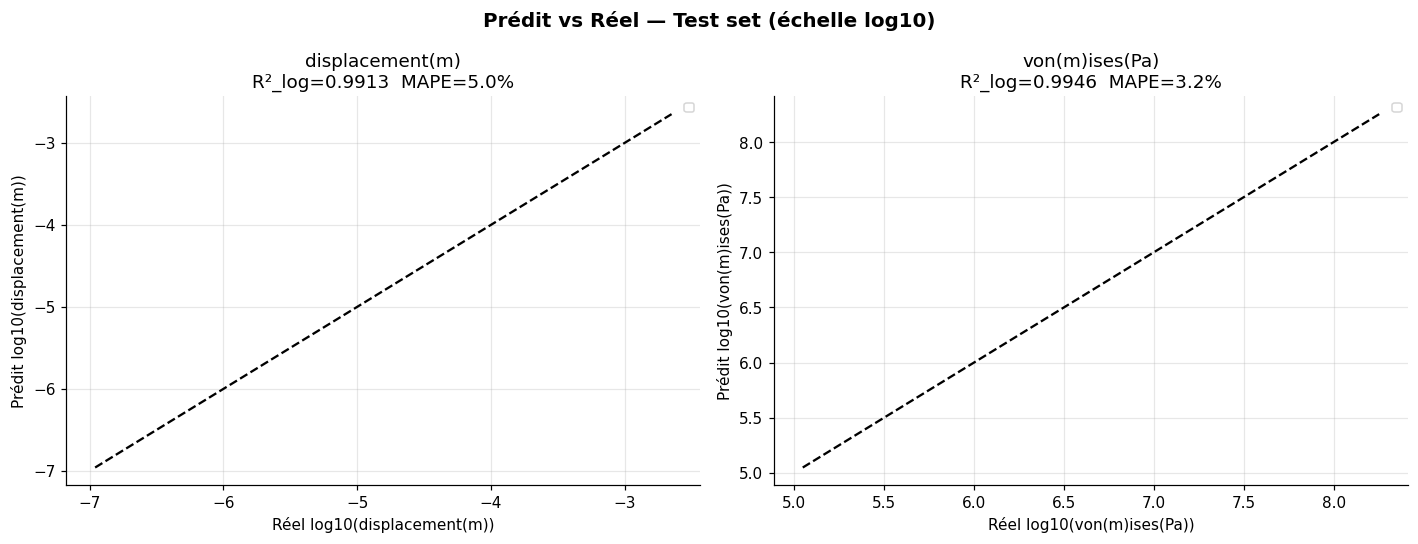

In [27]:
# ── Graphiques prédit vs réel ─────────────────────────────────────────────────
colors = {'with_hole': '#2196F3', 'with_hole_moving': '#FF5722', 'without_hole': '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Prédit vs Réel — Test set (échelle log10)', fontsize=13, fontweight='bold')

for ax, target in zip(axes, TARGET_COLS):
    m    = results[target]['test']
    geom = test['geometry_type']
    for geom_val, col in colors.items():
        mask = (geom == geom_val).values
        if mask.any():
            ax.scatter(m['y_log'][mask], m['p_log'][mask],
                       s=3, alpha=0.3, c=col, label=geom_val)
    lo, hi = m['y_log'].min(), m['y_log'].max()
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.5)
    short = target.replace('max_', '').replace('_m', '(m)').replace('_pa', '(Pa)')
    ax.set_xlabel(f'Réel log10({short})')
    ax.set_ylabel(f'Prédit log10({short})')
    ax.set_title(f'{short}\nR²_log={m["R2_log"]:.4f}  MAPE={m["MAPE"]*100:.1f}%')
    ax.legend(fontsize=8, markerscale=3)

plt.tight_layout()
plt.show()

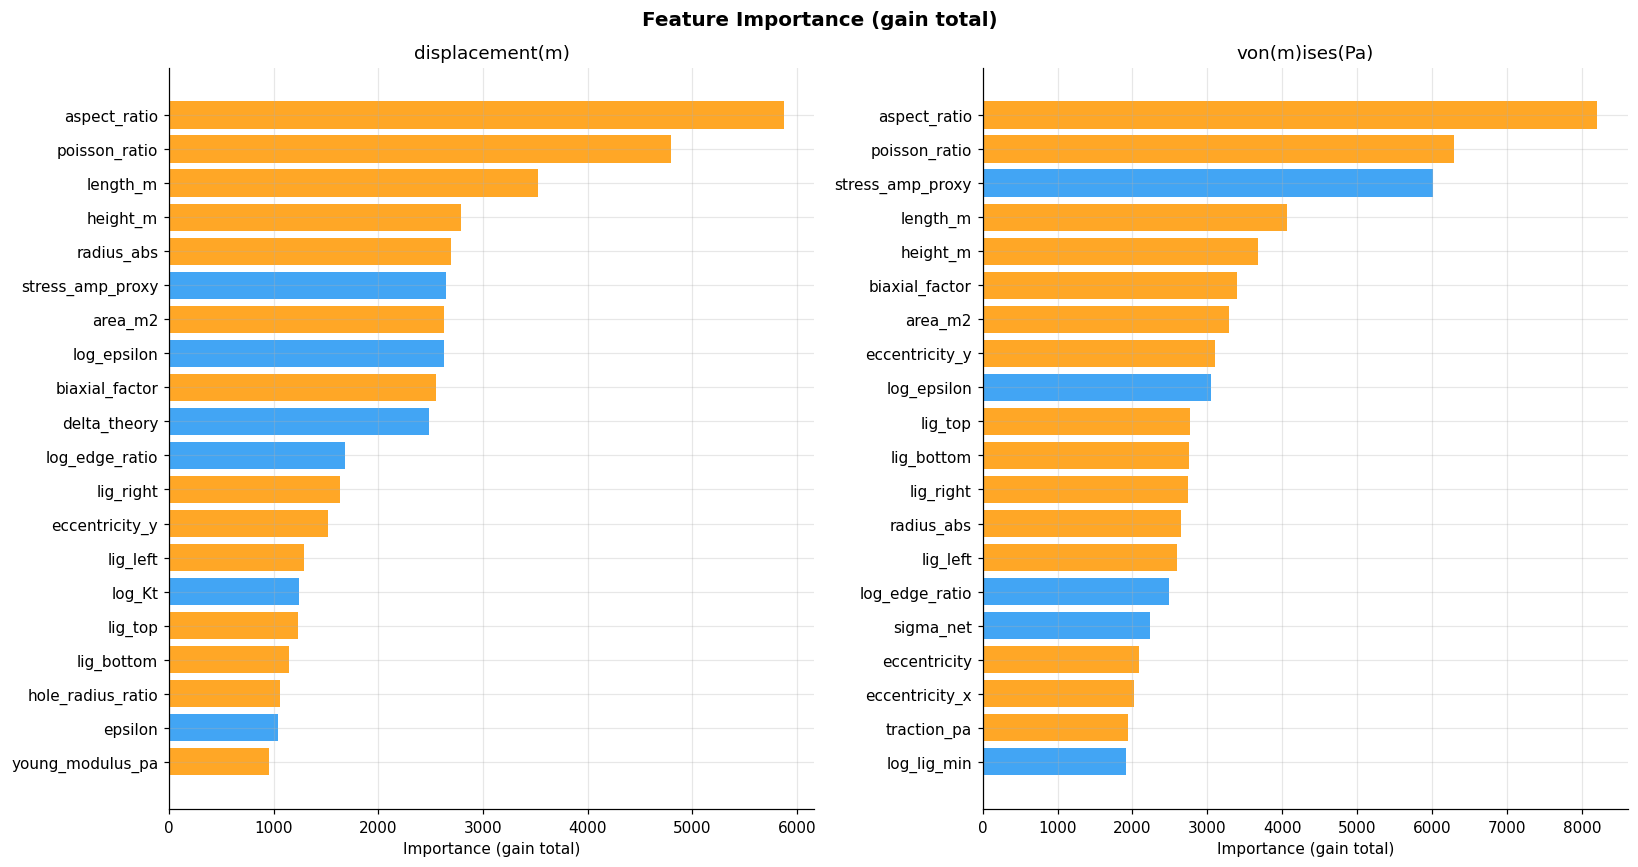

In [28]:
# ── Feature importance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Feature Importance (gain total)', fontsize=13, fontweight='bold')

for ax, target in zip(axes, TARGET_COLS):
    imp = pd.Series(trained_models[target].feature_importances_,
                    index=feat_cols).sort_values(ascending=True).tail(20)
    bar_colors = ['#2196F3' if any(k in f for k in
                  ['delta_theory', 'epsilon', 'sigma_net', 'Kt', 'stress_amp',
                   'log_', 'logE', 'logS'])
                  else '#FF9800' for f in imp.index]
    ax.barh(imp.index, imp.values, color=bar_colors, alpha=0.85)
    ax.set_xlabel('Importance (gain total)')
    ax.set_title(target.replace('max_', '').replace('_m', '(m)').replace('_pa', '(Pa)'))

plt.tight_layout()
plt.show()

---
## 6. Sauvegarde

In [29]:
# ── Sauvegarde des modèles ────────────────────────────────────────────────────
# Mettre OVERWRITE=True pour écraser les modèles existants.
OVERWRITE = False

for target in TARGET_COLS:
    path = MODEL_DIR / f'lgbm_{target}.joblib'
    if path.exists() and not OVERWRITE:
        print(f'[SKIP] {path.name} existe déjà. Mettre OVERWRITE=True pour écraser.')
        continue
    joblib.dump({
        'model':       trained_models[target],
        'feature_cols': feat_cols,
        'encoder':     enc,
        'target':      target,
        'best_params': best_params_per_target[target],
    }, path)
    print(f'[OK] Sauvegardé : {path}')

# Sauvegarde des métriques
rows = []
for target in TARGET_COLS:
    for split in ['val', 'test']:
        m = results[target][split]
        rows.append({
            'model': 'lgbm_log_transform_optuna' if USE_OPTUNA else 'lgbm_log_transform_manual',
            'target': target, 'split': split,
            'n_rows': len(val) if split == 'val' else len(test),
            'r2_log': m['R2_log'], 'rmse_log': m['RMSE_log'],
            'r2_orig': m['R2_orig'], 'rmse_orig': m['RMSE_orig'],
            'mae_orig': m['MAE_orig'], 'mape': m['MAPE'],
        })

metrics_path = MODEL_DIR / 'advanced_metrics.csv'
pd.DataFrame(rows).to_csv(metrics_path, index=False)
print(f'\nMétriques sauvegardées : {metrics_path}')

[SKIP] lgbm_max_displacement_m.joblib existe déjà. Mettre OVERWRITE=True pour écraser.
[SKIP] lgbm_max_von_mises_pa.joblib existe déjà. Mettre OVERWRITE=True pour écraser.

Métriques sauvegardées : ..\data\models\advanced\advanced_metrics.csv
